In [32]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import salem
import pandas as pd
import numpy as np
plt.style.use('bmh')
from scipy.stats import spearmanr
import os

In [34]:
clim_dir = '/home/chc-shrad/DATA/SIF/climatology/fusion_SCIAMACHY_GOME-2'
CROP_MASK_PATH = '/home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/crop_mask_fraction_on_sif_grid_conservative.nc'
crop_data = pd.read_csv('/home/chc-shrad/DATA/Crop_yield_forecasting/Crop_yield_reports/Harvest_stat/hvstat_africa_data_v1.0_20250212.csv')
#chirps = pd.read_hdf('/home/cape/CAPE/data_chirps3/data2/data_processed/prcp_chirps-v3.all.hdf')

In [35]:
## Reading SIF data and shape file
date_range = pd.date_range(start='2003-01-01', end='2017-12-31', freq='ME')
crop_mask = xr.open_dataset(CROP_MASK_PATH)
admin_shp = gpd.read_file('/home/chc-shrad/DATA/Crop_yield_forecasting/Crop_yield_reports/Harvest_stat/hvstat_boundary.gpkg')
sif_data = xr.open_mfdataset(f'/home/chc-shrad/DATA/SIF/fusion_SCIAMACHY_GOME-2/SIF_SCIAMACHY_GOME2_Harmonized.*_subsetted.nc4', 
                             concat_dim='time', combine='nested')
sif_data.coords['time'] = date_range

In [4]:
admin_correlation_results = []
for admin_name in admin_shp[admin_shp['ADMIN0']=='South Africa']['ADMIN1'].unique()[1:]:
    shdf = admin_shp[admin_shp['ADMIN1']==admin_name]
    sif_rt_sub = sif_data.salem.subset(shape=shdf, margin=2)
    crop_mask_sub = crop_mask.salem.subset(shape=shdf, margin=2)
    sif_yearly_max = sif_rt_sub.sel(time=sif_rt_sub['time.month'].isin([1,2,3])).groupby('time.year').max(dim='time')
    sif_yearly_max_masked = sif_yearly_max['SIF_740_daily_corr']*crop_mask_sub['crop_fraction']
    sif_yearly_max_masked = sif_yearly_max_masked.where(sif_yearly_max_masked>0, other=np.nan)
    aggregated_sif = sif_yearly_max_masked.sum(dim=['lon', 'lat'])
    crop_data_admin = crop_data[crop_data['admin_1']==admin_name]
    sel_crop_data_admin = crop_data_admin[(crop_data_admin['product']=='Maize') & (crop_data_admin['harvest_year'].isin(np.arange(2003, 2018)))][['harvest_year', 'yield']]
    aggregated_sif = aggregated_sif.sel(year=aggregated_sif.year.isin(sel_crop_data_admin['harvest_year']))
    correlation_sif, p_value_sif = spearmanr(aggregated_sif.values, sel_crop_data_admin['yield'].values)

    accumulated_chirps = chirps[shdf['FNID']].resample('ME').sum().rolling(window=6, center=False).sum()
    yearly_chirps = accumulated_chirps[(accumulated_chirps.index.month==3) & (accumulated_chirps.index.year>=2003) & (accumulated_chirps.index.year<=2017)]
    yearly_chirps.index = yearly_chirps.index.year

    yearly_chirps = yearly_chirps[yearly_chirps.index.isin(sel_crop_data_admin['harvest_year'])]
    correlation_chirps, p_value_chirps = spearmanr(yearly_chirps.values, sel_crop_data_admin['yield'].values)


    admin_correlation_results.append({'ADMIN_1': admin_name, 'correlation_sif': correlation_sif, 'p_value_sif': p_value_sif,
                                      'correlation_chirps': correlation_chirps, 'p_value_chirps': p_value_chirps})
admin_yield_SIF_correlation_df = pd.DataFrame(admin_correlation_results)

In [5]:
## masking crop mask for entire country
admin_names = admin_shp[admin_shp['ADMIN0']=='South Africa']['ADMIN1'].unique()[1:]
shdf = admin_shp[admin_shp['ADMIN1'].isin(admin_names)]
sif_rt_sub = sif_data.salem.subset(shape=shdf, margin=2)
crop_mask_sub = crop_mask.salem.subset(shape=shdf, margin=2)

Text(0.5, 1.0, 'Crop Fraction')

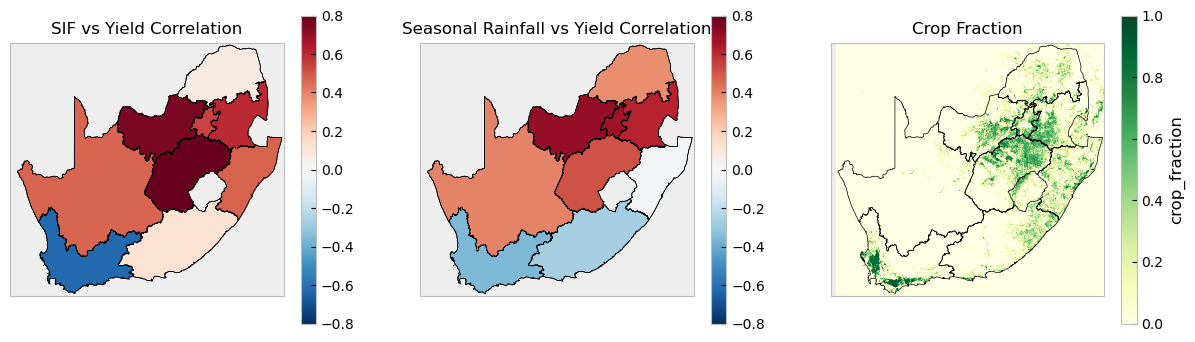

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), subplot_kw={'projection': ccrs.PlateCarree()})
cmap = 'RdBu_r'
axes = axes.flatten()
axes[0].set_extent([16, 33, -35, -22])
axes[0].set_title('SIF vs Yield Correlation', fontsize=12)
merge_gpd = pd.merge(admin_yield_SIF_correlation_df, admin_shp[['ADMIN1', 'geometry']], left_on='ADMIN_1', right_on='ADMIN1')
merge_gpd = gpd.GeoDataFrame(merge_gpd, geometry='geometry', crs=admin_shp.crs)
merge_gpd.plot(ax=axes[0], column='correlation_sif', cmap=cmap, vmin=-0.8, vmax=0.8, legend=True, edgecolor='black')
shdf.plot(ax=axes[0], facecolor='none', edgecolor='black')

axes[1].set_extent([16, 33, -35, -22])
axes[1].set_title('Seasonal Rainfall vs Yield Correlation', fontsize=12)
merge_gpd = pd.merge(admin_yield_SIF_correlation_df, admin_shp[['ADMIN1', 'geometry']], left_on='ADMIN_1', right_on='ADMIN1')
merge_gpd = gpd.GeoDataFrame(merge_gpd, geometry='geometry', crs=admin_shp.crs)
merge_gpd.plot(ax=axes[1], column='correlation_chirps', cmap=cmap, vmin=-0.8, vmax=0.8, legend=True, edgecolor='black')
shdf.plot(ax=axes[1], facecolor='none', edgecolor='black')

axes[2].set_extent([16, 33, -35, -22])

crop_mask_sub['crop_fraction'].plot(ax=axes[2], cmap='YlGn', vmin=0, vmax=1)
shdf.plot(ax=axes[2], facecolor='none', edgecolor='black')
axes[2].set_title('Crop Fraction', fontsize=12)



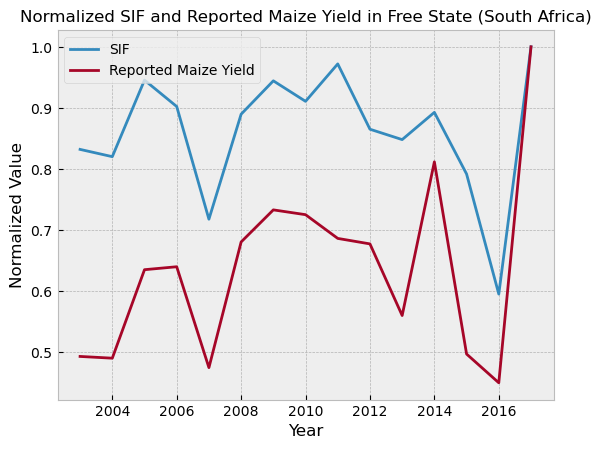

In [7]:
admin_name = 'Free State'
shdf = admin_shp[admin_shp['ADMIN1']==admin_name]
sif_rt_sub = sif_data.salem.subset(shape=shdf, margin=2)
crop_mask_sub = crop_mask.salem.subset(shape=shdf, margin=2)
sif_yearly_max = sif_rt_sub.sel(time=sif_rt_sub['time.month'].isin([1,2,3])).groupby('time.year').max(dim='time')
sif_yearly_max_masked = sif_yearly_max['SIF_740_daily_corr']*crop_mask_sub['crop_fraction']
sif_yearly_max_masked = sif_yearly_max_masked.where(sif_yearly_max_masked>0, other=np.nan)
aggregated_sif = sif_yearly_max_masked.sum(dim=['lon', 'lat'])
crop_data_admin = crop_data[crop_data['admin_1']==admin_name]
sel_crop_data_admin = crop_data_admin[(crop_data_admin['product']=='Maize') & (crop_data_admin['harvest_year'].isin(np.arange(2003, 2018)))][['harvest_year', 'yield']]
aggregated_sif = aggregated_sif.sel(year=aggregated_sif.year.isin(sel_crop_data_admin['harvest_year']))

plt.plot(aggregated_sif.year, aggregated_sif.values/aggregated_sif.values.max(), label='SIF')
plt.plot(sel_crop_data_admin['harvest_year'], sel_crop_data_admin['yield']/sel_crop_data_admin['yield'].max(), label='Reported Maize Yield')
plt.xlabel('Year')
plt.ylabel('Normalized Value')
plt.title('Normalized SIF and Reported Maize Yield in Free State (South Africa)', fontsize=12)
plt.legend()

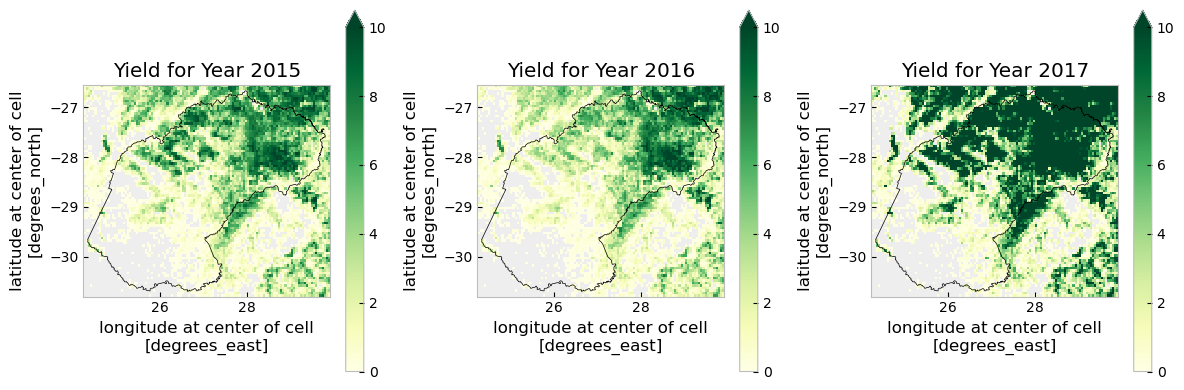

In [ ]:
## Calculating SIF weights and downscaling yield

admin_name = 'Free State'
shdf = admin_shp[admin_shp['ADMIN1']==admin_name]
sif_rt_sub = sif_data.salem.subset(shape=shdf, margin=2)
crop_mask_sub = crop_mask.salem.subset(shape=shdf, margin=2)
sif_yearly_max = sif_rt_sub.sel(time=sif_rt_sub['time.month'].isin([1,2,3])).groupby('time.year').max(dim='time')
sif_yearly_max_masked = sif_yearly_max['SIF_740_daily_corr']*crop_mask_sub['crop_fraction']
sif_yearly_max_masked = sif_yearly_max_masked.where(sif_yearly_max_masked>0, other=np.nan)

## selecting crop yield data for the specific admin region
crop_data_admin = crop_data[crop_data['admin_1']==admin_name]
sel_crop_data_admin = crop_data_admin[(crop_data_admin['product']=='Maize') & (crop_data_admin['harvest_year'].isin(np.arange(2003, 2018)))][['harvest_year', 'yield']]
# Creating a DataArray for yield data with the same time dimension as the SIF data
yield_da = xr.DataArray(
    sel_crop_data_admin['yield'].values,
    coords={'year': sif_yearly_max_masked.year.values},
    dims=['year']
)

sif_weight = sif_yearly_max_masked / sif_yearly_max_masked.max(dim=['lon', 'lat'])
# --- Approach 2: Sum-normalized weights (spatial mean == admin yield) ---
# Normalise so weights sum to 1, then rescale by number of valid pixels → mean preserved
n_pixels = sif_weight.count(dim=['lon', 'lat'])
sif_weight_norm = (sif_weight / sif_weight.sum(dim=['lon', 'lat'])) * n_pixels
downscaled_yield_conserved = sif_weight_norm * yield_da

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes = axes.flatten()

for cnt, year, in enumerate([2015, 2016, 2017]):
    ax= axes[cnt]
    downscaled_yield_conserved.sel(year=year).plot(ax=axes[cnt], cmap='YlGn', vmin=0, vmax=10)
    ax.set_title('Yield for Year {}'.format(year))
    shdf.plot(ax=ax, facecolor='none', edgecolor='black')

downscaled_yield_mean = downscaled_yield_conserved.mean(dim='year')
downscaled_yield_std = downscaled_yield_conserved.std(dim='year')
downscaled_yield_std
plt.tight_layout()


In [4]:
## Reading SIF data and shape file
date_range = pd.date_range(start='2003-01-01', end='2017-12-31', freq='ME')
crop_mask = xr.open_dataset(CROP_MASK_PATH)
admin_shp = gpd.read_file('/home/chc-shrad/DATA/Crop_yield_forecasting/Crop_yield_reports/Harvest_stat/hvstat_boundary.gpkg')
sif_data = xr.open_mfdataset(f'/home/chc-shrad/DATA/SIF/fusion_SCIAMACHY_GOME-2/SIF_SCIAMACHY_GOME2_Harmonized.*_subsetted.nc4', 
                             concat_dim='time', combine='nested')
sif_data.coords['time'] = date_range

In [5]:
## Downscaling yield using SIF data
country, crop_type, crop_production_system, season_name, admin_type = 'South Africa', 'Maize', 'Commercial (PS)', 'Summer', 'ADMIN1'

for admin_name in admin_shp[admin_shp['ADMIN0']==country][admin_type].unique()[1:]:
    fnid = admin_shp[admin_shp[admin_type]==admin_name]['FNID'].values[0]
    # Extracting SIF and crop mask data for the specific admin region
    shdf = admin_shp[admin_shp[admin_type]==admin_name]
    sif_rt_sub = sif_data.salem.subset(shape=shdf, margin=2)
    crop_mask_sub = crop_mask.salem.subset(shape=shdf, margin=2)

    ## selecting crop yield data for the specific admin region and crop type
    if admin_type.lower() == 'admin1':
        crop_admin_type = 'admin_1'
    elif admin_type.lower() == 'admin2':
        crop_admin_type = 'admin_2'
    elif admin_type.lower() == 'admin3':
        crop_admin_type = 'admin_3'

    crop_data_admin = crop_data[crop_data[crop_admin_type]==admin_name]
    sel_crop_data_admin = crop_data_admin[(crop_data_admin['product']==crop_type) & (crop_data_admin['harvest_year'].isin(np.arange(2003, 2018)))][['planting_year', 'planting_month', 'harvest_year', 'harvest_month', 'yield']]
    
    # Inspect season table (already prepared)
    sel_crop_data_admin = sel_crop_data_admin.sort_values('harvest_year').reset_index(drop=True)

    # Build seasonal SIF max using planting/harvest timing from each row
    seasonal_max_list = []

    for _, row in sel_crop_data_admin.iterrows():
        p_year = int(row['planting_year'])
        p_month = int(row['planting_month'])
        h_year = int(row['harvest_year'])
        h_month = int(row['harvest_month'])

        # Season window: from first day of planting month to end of harvest month
        season_start = pd.Timestamp(p_year, p_month, 1)
        season_end = pd.Timestamp(h_year, h_month, 1) + pd.offsets.MonthEnd(1)

        sif_season = sif_rt_sub.sel(time=slice(season_start, season_end))['SIF_740_daily_corr']

        if sif_season.sizes.get('time', 0) > 0:
            season_max = sif_season.max(dim='time', skipna=True)
        else:
            season_max = sif_rt_sub['SIF_740_daily_corr'].isel(time=0) * np.nan

        season_max = season_max.expand_dims(year=[h_year])
        seasonal_max_list.append(season_max)

    # Final DataArray: (year, lat, lon) with one max map per growing season year
    sif_yearly_max = xr.concat(seasonal_max_list, dim='year')

    sif_yearly_max_masked = sif_yearly_max*crop_mask_sub['crop_fraction']
    sif_yearly_max_masked = sif_yearly_max_masked.where(sif_yearly_max_masked>0, other=np.nan)

    # Creating a DataArray for yield data with the same time dimension as the SIF data
    yield_da = xr.DataArray(
            sel_crop_data_admin['yield'].values,
            coords={'year': sif_yearly_max_masked.year.values},
            dims=['year']
        )

    sif_weight = sif_yearly_max_masked / sif_yearly_max_masked.max(dim=['lon', 'lat'])

    # Normalise so weights sum to 1, then rescale by number of valid pixels → mean preserved
    n_pixels = sif_weight.count(dim=['lon', 'lat'])
    sif_weight_norm = (sif_weight / sif_weight.sum(dim=['lon', 'lat'])) * n_pixels
    downscaled_yield_conserved = sif_weight_norm * yield_da

    outdir = '/home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based'
    os.makedirs(outdir, exist_ok=True)
    outfile = f'{outdir}/downscaled_yield_fnid_{fnid}_{country.replace(" ", "_")}_{admin_name.replace(" ", "_")}.nc'
    print (f'Saving downscaled yield for {admin_name} to {outfile}')
    downscaled_yield_conserved.to_netcdf(outfile)


Saving downscaled yield for Western Cape to /home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downscaled_yield_fnid_ZA1994A101_South_Africa_Western_Cape.nc
Saving downscaled yield for Eastern Cape to /home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downscaled_yield_fnid_ZA1994A102_South_Africa_Eastern_Cape.nc


/home/sshukla/miniforge3/envs/py312/lib/python3.12/site-packages/dask/array/reductions.py:654: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


Saving downscaled yield for Northern Cape to /home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downscaled_yield_fnid_ZA1994A103_South_Africa_Northern_Cape.nc
Saving downscaled yield for Free State to /home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downscaled_yield_fnid_ZA1994A104_South_Africa_Free_State.nc
Saving downscaled yield for Kwazulu-Natal to /home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downscaled_yield_fnid_ZA1994A105_South_Africa_Kwazulu-Natal.nc
Saving downscaled yield for North West to /home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downscaled_yield_fnid_ZA1994A106_South_Africa_North_West.nc
Saving downscaled yield for Gauteng to /home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downscaled_yield_fnid_ZA1994A107_South_Africa_Gauteng.nc
Saving downscaled yield for Mpumalanga to /home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_base

'ZA1994A109'

In [40]:
crop_data_admin = crop_data[crop_data[crop_admin_type]==admin_name]
crop_data_admin[crop_data_admin['product']=='Maize']

,fnid,country,country_code,admin_1,admin_2,product,season_name,planting_year,planting_month,harvest_year,harvest_month,crop_production_system,QC_flag,area,production,yield
177018,ZA1994A109,South Africa,ZA,Limpopo,none,Maize,Summer,1986,10,1987,4,Commercial (PS),0,56000.0,101000.0,1.803571
177019,ZA1994A109,South Africa,ZA,Limpopo,none,Maize,Summer,1987,10,1988,4,Commercial (PS),0,71000.0,92000.0,1.295775
177020,ZA1994A109,South Africa,ZA,Limpopo,none,Maize,Summer,1988,10,1989,4,Commercial (PS),0,42000.0,91000.0,2.166667
177021,ZA1994A109,South Africa,ZA,Limpopo,none,Maize,Summer,1989,10,1990,4,Commercial (PS),0,34000.0,55000.0,1.617647
177022,ZA1994A109,South Africa,ZA,Limpopo,none,Maize,Summer,1990,10,1991,4,Commercial (PS),0,31000.0,82000.0,2.645161
177023,ZA1994A109,South Africa,ZA,Limpopo,none,Maize,Summer,1991,10,1992,4,Commercial (PS),0,36000.0,22000.0,0.611111
177024,ZA1994A109,South Africa,ZA,Limpopo,none,Maize,Summer,1992,10,1993,4,Commercial (PS),0,35000.0,45000.0,1.285714
177025,ZA1994A109,South Africa,ZA,Limpopo,none,Maize,Summer,1993,10,1994,4,Commercial (PS),0,34399.0,72000.0,2.093084
177026,ZA1994A109,South Africa,ZA,Limpopo,none,Maize,Summer,1994,10,1995,4,Commercial (PS),0,19500.0,23000.0,1.179487
177027,ZA1994A109,South Africa,ZA,Limpopo,none,Maize,Summer,1995,10,1996,4,Commercial (PS),0,16000.0,52000.0,3.250000


In [20]:
sif_season.sizes.get('time', 0)

7

In [19]:
sif_season

<xarray.DataArray 'SIF_740_daily_corr' (time: 7, lat: 67, lon: 113)> Size: 212kB
dask.array<getitem, shape=(7, 67, 113), dtype=float32, chunksize=(1, 67, 113), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 536B -25.38 -25.33 -25.28 ... -22.18 -22.13 -22.08
  * lon      (lon) float64 904B 26.33 26.38 26.43 26.48 ... 31.83 31.88 31.93
  * time     (time) datetime64[ns] 56B 2016-10-31 2016-11-30 ... 2017-04-30
Attributes:
    units:                mW/m2/nm/sr
    long_name:            daily-corrected SIF at 740nm
    ancillary_variables:  SIF_740_daily_corr_SD
    grid_mapping:         crs

In [ ]:

    sif_yearly_max = sif_rt_sub.sel(time=sif_rt_sub['time.month'].isin([1,2,3])).groupby('time.year').max(dim='time')
    

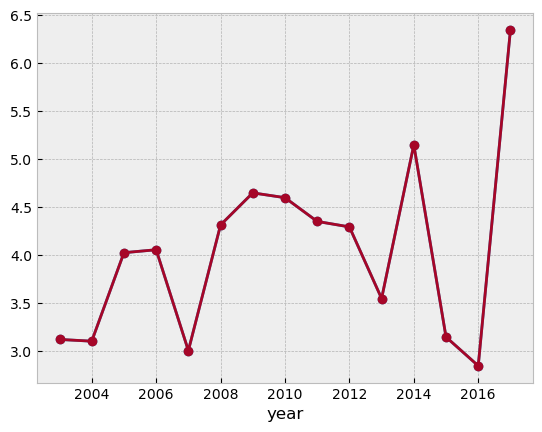

In [14]:
downscaled_yield_conserved.mean(dim=['lon', 'lat']).plot(label='Downscaled Yield (Conserved)', marker='o')
plt.plot(sel_crop_data_admin['harvest_year'], sel_crop_data_admin['yield'], label='Selected Crop Data', marker='o')


In [9]:
spam_data = xr.open_dataset('/home/chc-shrad/DATA/Crop_yield_forecasting/Crop_yield_reports/SPAM/spam2020V2r2_global_yield/spam2020_V2r2_global_Y_MAIZ_A.tif')

In [2]:
ls /home/chc-shrad/DATA/Crop_yield_forecasting/Crop_yield_reports/SPAM/spam2020V2r2_global_yield/

spam2020_V2r2_global_Y_BANA_A.tif  spam2020_V2r2_global_Y_PLNT_A.tif
spam2020_V2r2_global_Y_BANA_I.tif  spam2020_V2r2_global_Y_PLNT_I.tif
spam2020_V2r2_global_Y_BANA_R.tif  spam2020_V2r2_global_Y_PLNT_R.tif
spam2020_V2r2_global_Y_BARL_A.tif  spam2020_V2r2_global_Y_PMIL_A.tif
spam2020_V2r2_global_Y_BARL_I.tif  spam2020_V2r2_global_Y_PMIL_I.tif
spam2020_V2r2_global_Y_BARL_R.tif  spam2020_V2r2_global_Y_PMIL_R.tif
spam2020_V2r2_global_Y_BEAN_A.tif  spam2020_V2r2_global_Y_POTA_A.tif
spam2020_V2r2_global_Y_BEAN_I.tif  spam2020_V2r2_global_Y_POTA_I.tif
spam2020_V2r2_global_Y_BEAN_R.tif  spam2020_V2r2_global_Y_POTA_R.tif
spam2020_V2r2_global_Y_CASS_A.tif  spam2020_V2r2_global_Y_RAPE_A.tif
spam2020_V2r2_global_Y_CASS_I.tif  spam2020_V2r2_global_Y_RAPE_I.tif
spam2020_V2r2_global_Y_CASS_R.tif  spam2020_V2r2_global_Y_RAPE_R.tif
spam2020_V2r2_global_Y_CHIC_A.tif  spam2020_V2r2_global_Y_RCOF_A.tif
spam2020_V2r2_global_Y_CHIC_I.tif  spam2020_V2r2_global_Y_RCOF_I.tif
spam2020_V2r2_global_Y_CHIC_R.tif 

In [ ]:
import xarray as xr
gosif_v2 = xr.open_mfdataset('/home/chc-shrad/DATA/SIF/GOSIF_v2/netcdf/monthly/GOSIF_v2_*', combine='nested', concat_dim='time')

yearly_mean = gosif_v2['SIF'].groupby('time.year').mean(dim='time')
years = yearly_mean.year.values

ncols = 6
nrows = int(np.ceil(len(years) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i, year in enumerate(years):
    yearly_mean.sel(year=year).plot(ax=axes[i], cmap='YlGn', vmin=0, vmax=1, add_colorbar=False)
    axes[i].set_title(str(year))
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('GOSIF v2 Yearly Mean SIF', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

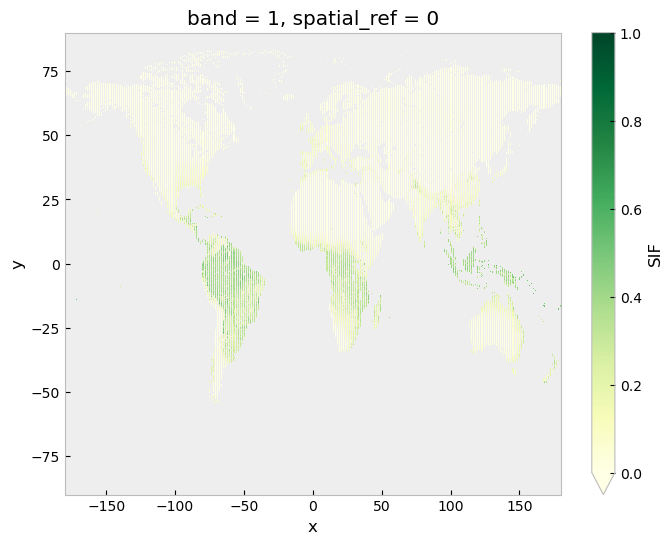

In [40]:
gosif_v2['SIF'].sel(time=(gosif_v2.coords['time.month']==3) & (gosif_v2.coords['time.year']>=2003) & (gosif_v2.coords['time.year']<=2018)).mean(dim='time').plot(vmin=0, vmax=1, cmap='YlGn', figsize=(8, 6))

In [29]:
sel_go_sif = gosif_v2['SIF'].sel(y=slice(40, -36), x=slice(-25, 52), time=(gosif_v2.coords['time.month']==3) & (gosif_v2.coords['time.year']>=2003) & (gosif_v2.coords['time.year']<=2018))
sel_go_sif_mean = sel_go_sif.mean(dim='time')
sel_go_sif_std = sel_go_sif.std(dim='time')

In [36]:
sif_data_mean = sif_data['SIF_740_daily_corr'].sel(lat=slice(-36, 40), lon=slice(-25, 52)).mean(dim='time')
sif_data_std = sif_data['SIF_740_daily_corr'].sel(lat=slice(-36, 40), lon=slice(-25, 52)).std(dim='time')

In [33]:
tiff = xr.open_dataset('/home/chc-shrad/DATA/SIF/GOSIF_v2/tiff/GOSIF_v2/monthly/GOSIF_2000.M03.tif', engine='rasterio')

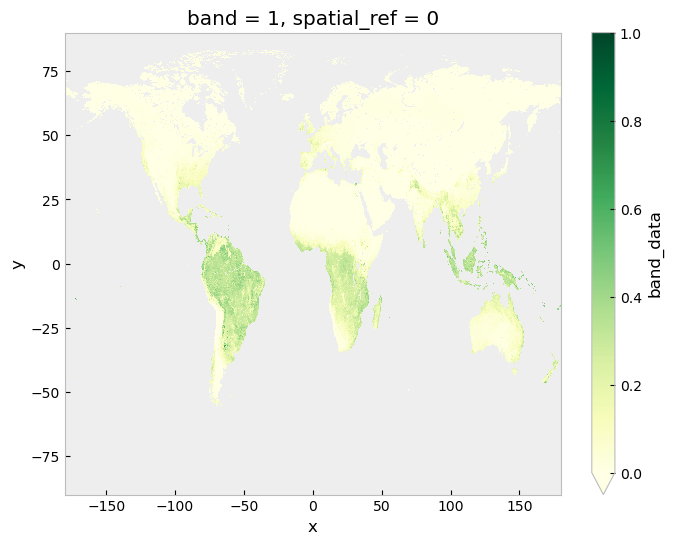

In [39]:
da = tiff['band_data'].isel(band=0)*0.0001
da.where(da < 2, other=np.nan).plot(vmin=0, vmax=1, cmap='YlGn', figsize=(8, 6))